In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

In [2]:
def hillas_from_image(
    image_1d: np.ndarray,
    *,
    shape=(32, 32),
    pixel_pitch=1.0,
    pixel_coords: np.ndarray | None = None,
    event_id: int = 1,
    telescope_id: int = 1,
    timestamp: float | None = None,
) -> pd.DataFrame:
    """
    Berechnet Hillas-Parameter aus einem gecleanten Kamerabild.

    Parameter
    ---------
    image_1d : np.ndarray
        1D-Array mit Pixel-Signalen (z.B. ADC / photo-electrons). Zeros gelten als 'ausmaskiert'.
    shape : (int, int)
        Rasterform, falls pixel_coords nicht gesetzt ist (z.B. (32,32)).
    pixel_pitch : float
        Abstand benachbarter Pixel (in gleichen Einheiten wie gewünschte Ausgaben).
    pixel_coords : np.ndarray[ N, 2 ] | None
        Optionale Pixelkoordinaten (x, y) für jedes Pixel im image_1d.
        Falls None, wird ein reguläres shape-Gitter angenommen, mit Ursprung im Bildzentrum.
    event_id, telescope_id, timestamp : Metadaten

    Rückgabe
    --------
    pd.DataFrame mit Spalten:
      Event, Telescope, Timestamp, MeanX, StdX, MeanY, StdY, Phi, Size,
      Length, Width, Miss, Distance, Azwidth, Alpha
    """

    q = np.asarray(image_1d, dtype=float)
    if q.ndim != 1:
        raise ValueError("image_1d muss 1D sein (gecleantes flaches Array).")

    N = q.size

    # Pixelkoordinaten bestimmen
    if pixel_coords is not None:
        coords = np.asarray(pixel_coords, dtype=float)
        if coords.shape != (N, 2):
            raise ValueError(f"pixel_coords muss Form (N,2) mit N={N} haben.")
        x, y = coords[:, 0], coords[:, 1]
    else:
        # Reguläres Gitter annehmen und in Bildmitte zentrieren
        ny, nx = shape
        if nx * ny != N:
            raise ValueError(f"shape {shape} passt nicht zur Länge des Arrays (N={N}).")
        yy, xx = np.mgrid[0:ny, 0:nx]
        # Ursprung ins Zentrum legen (0,0) in der geometrischen Bildmitte
        xx = (xx - (nx - 1) / 2.0) * pixel_pitch
        yy = (yy - (ny - 1) / 2.0) * pixel_pitch
        x = xx.ravel()
        y = yy.ravel()

    # Nur positive/aktive Pixel verwenden
    mask = q > 0
    if not np.any(mask):
        # Keine aktiven Pixel -> NaNs zurückgeben
        cols = ["Event","Telescope","Timestamp","MeanX","StdX","MeanY","StdY","Phi",
                "Size","Length","Width","Miss","Distance","Azwidth","Alpha"]
        return pd.DataFrame([{c: np.nan for c in cols}] | [{"Event": event_id, "Telescope": telescope_id, "Timestamp": timestamp}]).ffill()

    x = x[mask]
    y = y[mask]
    q = q[mask]

    size = q.sum()
    if size <= 0:
        raise ValueError("Summe der Signale (Size) ist <= 0.")

    # Schwerpunkt (gewichtet)
    meanx = (q * x).sum() / size
    meany = (q * y).sum() / size

    # Zentrale 2. Momente (gewichtete Kovarianzmatrix)
    dx = x - meanx
    dy = y - meany
    Sxx = (q * dx * dx).sum() / size
    Syy = (q * dy * dy).sum() / size
    Sxy = (q * dx * dy).sum() / size
    cov = np.array([[Sxx, Sxy],
                    [Sxy, Syy]])

    # Standardabweichungen entlang x/y (nur informativ)
    stdx = np.sqrt(Sxx) if Sxx >= 0 else np.nan
    stdy = np.sqrt(Syy) if Syy >= 0 else np.nan

    # Eigenzerlegung -> Haupt- und Nebenachse
    # Länge^2 = größtes Eigenvalue, Breite^2 = kleinstes Eigenvalue
    evals, evecs = np.linalg.eigh(cov)  # symmetrisch -> sortiert aufsteigend
    width2, length2 = evals[0], evals[1]
    width  = np.sqrt(max(width2, 0.0))
    length = np.sqrt(max(length2, 0.0))

    # Richtungsvektor der Hauptachse (zu length gehöriger Eigenvektor)
    u = evecs[:, 1]  # Eigenvektor zu größtem EV
    ux, uy = float(u[0]), float(u[1])

    # Orientierungswinkel Phi in Grad (0..180), gemessen von +x-Achse
    phi = np.degrees(np.arctan2(uy, ux)) % 180.0

    # Distanz Schwerpunkt -> Kamerazentrum
    dist = np.hypot(meanx, meany)

    # MISS: kürzester Abstand des Kamerazentrums (0,0) zur Hauptachse durch den Schwerpunkt
    # Formel (Vorzeichen egal): miss = | sin(phi)*meanx - cos(phi)*meany |
    # (alternativ: |(-sin(phi), cos(phi)) · (0-mean)| )
    sinp, cosp = np.sin(np.radians(phi)), np.cos(np.radians(phi))
    miss = abs(sinp * meanx - cosp * meany)

    # ALPHA: Winkel zwischen Hauptachse u und der Richtung vom Schwerpunkt zum Kamerazentrum
    # v = norm( -[meanx, meany] )
    if dist > 0:
        vx, vy = -meanx / dist, -meany / dist
        alpha = np.degrees(np.arccos(np.clip(abs(ux * vx + uy * vy), -1.0, 1.0)))
    else:
        alpha = 0.0

    # AZWIDTH: zweite Momente senkrecht zur Verbindungsrichtung Schwerpunkt -> Zentrum
    # ê_r = norm( -[meanx, meany] ), ê_perp = (-ê_r_y, ê_r_x)
    # azwidth^2 = ê_perp^T Σ ê_perp
    if dist > 0:
        erx, ery = -meanx / dist, -meany / dist
        eperp = np.array([-ery, erx])
        azwidth2 = eperp @ cov @ eperp
        azwidth = np.sqrt(max(azwidth2, 0.0))
    else:
        azwidth = width  # symmetrischer Grenzfall

    # Ergebnis-DataFrame
    out = pd.DataFrame([{
        "Event": event_id,
        "Telescope": telescope_id,
        "Timestamp": timestamp,
        "MeanX": meanx,
        "StdX": stdx,
        "MeanY": meany,
        "StdY": stdy,
        "Phi": phi,                 # Grad
        "Size": size,
        "Length": length,           # sqrt größtes EV (in PixelPitch-Einheiten)
        "Width": width,             # sqrt kleinstes EV
        "Miss": miss,
        "Distance": dist,
        "Azwidth": azwidth,
        "Alpha": alpha              # Grad
    }])

    return out


# --- Optional: Stapelverarbeitung für viele Ereignisse ---
def hillas_for_events(
    images_1d: list[np.ndarray],
    *,
    shape=(32, 32),
    pixel_pitch=1.0,
    pixel_coords: np.ndarray | None = None,
    event_ids: list[int] | None = None,
    telescope_id: int = 1,
    timestamps: list[float] | None = None,
) -> pd.DataFrame:
    """
    Wendet hillas_from_image auf eine Liste von Events an und konkateniert die DataFrames.
    """
    n = len(images_1d)
    if event_ids is None:
        event_ids = list(range(1, n + 1))
    if timestamps is None:
        timestamps = [None] * n
    if len(event_ids) != n or len(timestamps) != n:
        raise ValueError("Längen von event_ids/timestamps müssen zu images_1d passen.")

    dfs = []
    for img, eid, ts in zip(images_1d, event_ids, timestamps):
        df = hillas_from_image(
            img,
            shape=shape,
            pixel_pitch=pixel_pitch,
            pixel_coords=pixel_coords,
            event_id=eid,
            telescope_id=telescope_id,
            timestamp=ts,
        )
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

In [5]:
def plot_hillas_from_df(
    image_1d: np.ndarray,
    df,
    *,
    event_id: int,
    telescope_id: int,
    shape=(32, 32),
    pixel_pitch: float = 1.0,
    pixel_coords: np.ndarray | None = None,
    k_sigma: float = 2.0,
    cmap: str = "plasma",
    mask_zeros_to_white: bool = True,
    vmin: float | None = None,
    vmax: float | None = None,
    show_colorbar: bool = True,
    axes_equal: bool = True,
    title: str | None = None,
    savepath: str | None = None,
):
    """
    Plottet das Kamerabild und überlagert die Hillas-Ellipse aus einem DataFrame.

    image_1d : 1D numpy array mit gecleanten Pixelwerten
    df       : pandas.DataFrame mit Spalten wie aus hillas_from_image()
    event_id, telescope_id : bestimmen die Zeile, die geplottet werden soll
    """

    # passende Zeile im DataFrame holen
    sel = df.query("Event == @event_id and Telescope == @telescope_id")
    if sel.empty:
        raise ValueError(f"Kein Eintrag für Event {event_id}, Telescope {telescope_id}")
    row = sel.iloc[0]

    # Parameter extrahieren
    meanx, meany = row["MeanX"], row["MeanY"]
    phi_deg = row["Phi"]
    length, width = row["Length"], row["Width"]
    miss, dist, alpha, size = row["Miss"], row["Distance"], row["Alpha"], row["Size"]

    fig, ax = plt.subplots(figsize=(6.5, 6))
    q = np.asarray(image_1d, dtype=float)
    N = q.size

    # === Kamerabild zeichnen ===
    if pixel_coords is None:
        ny, nx = shape
        if nx * ny != N:
            raise ValueError(f"shape {shape} passt nicht zur Arraylänge N={N}.")
        x_edges = (np.arange(nx + 1) - (nx - 1) / 2.0 - 0.5) * pixel_pitch
        y_edges = (np.arange(ny + 1) - (ny - 1) / 2.0 - 0.5) * pixel_pitch
        img2d = q.reshape(ny, nx)

        if mask_zeros_to_white:
            img_masked = np.ma.masked_where(img2d == 0, img2d)
            cmap_use = plt.cm.get_cmap(cmap).copy()
            cmap_use.set_bad(color="white")
            im = ax.pcolormesh(x_edges, y_edges, img_masked,
                               shading="flat", cmap=cmap_use,
                               vmin=vmin, vmax=vmax)
        else:
            im = ax.pcolormesh(x_edges, y_edges, img2d,
                               shading="flat", cmap=cmap,
                               vmin=vmin, vmax=vmax)
    else:
        coords = np.asarray(pixel_coords, dtype=float)
        if coords.shape != (N, 2):
            raise ValueError(f"pixel_coords muss Form (N,2) mit N={N} haben.")
        x, y = coords[:, 0], coords[:, 1]
        if mask_zeros_to_white:
            ax.scatter(x, y, s=20, c="white", marker="s", edgecolors="none")
            active = q > 0
            im = ax.scatter(x[active], y[active], s=20, c=q[active],
                            cmap=cmap, vmin=vmin, vmax=vmax, marker="s")
        else:
            im = ax.scatter(x, y, s=20, c=q, cmap=cmap,
                            vmin=vmin, vmax=vmax, marker="s")

    if show_colorbar:
        cbar = fig.colorbar(im, ax=ax)
        cbar.set_label("Signal")

    # === Hillas-Ellipse zeichnen ===
    a, b = k_sigma * length, k_sigma * width
    ell = Ellipse((meanx, meany), width=2 * a, height=2 * b,
                  angle=phi_deg, fill=False, lw=2.0)
    ax.add_patch(ell)

    phi = np.deg2rad(phi_deg)
    ax.plot([meanx - a*np.cos(phi), meanx + a*np.cos(phi)],
            [meany - a*np.sin(phi), meany + a*np.sin(phi)], lw=1.5)
    ax.plot([meanx - b*np.sin(phi), meanx + b*np.sin(phi)],
            [meany + b*np.cos(phi), meany - b*np.cos(phi)], lw=1.0, ls="--")

    ax.plot(meanx, meany, 'ko', ms=5)
    ax.plot([0, meanx], [0, meany], 'k:', lw=1.0)

    txt = (f"Event {event_id}, Tel {telescope_id}\n"
           f"Size={size:.1f}  Phi={phi_deg:.1f}°  Alpha={alpha:.1f}°\n"
           f"Length={length:.2f}  Width={width:.2f}  Miss={miss:.2f}  Dist={dist:.2f}")
    ax.text(0.02, 0.98, txt, transform=ax.transAxes, va="top", ha="left",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7), fontsize=9)

    if axes_equal:
        ax.set_aspect("equal", "box")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(alpha=0.2)
    ax.set_title(title or "Kamerabild mit Hillas-Ellipse")

    if savepath:
        fig.savefig(savepath, dpi=150, bbox_inches="tight")

    return fig, ax

In [10]:
data=np.load("crab_2025-10-20_data_cleaned_SNR7.npy")
timestamps=np.load("crab_2025-10-20_timestamp_cleaned_SNR7.npy")
df=hillas_for_events(data,pixel_pitch=0.31,timestamps=timestamps)
print(df)
df.to_csv("crab_2025-10-20_hillas_SNR7.csv", index=False)

      Event  Telescope     Timestamp     MeanX      StdX     MeanY      StdY  \
0         1          1  1.760943e+09 -1.158618  0.296773 -3.054481  0.376488   
1         2          1  1.760943e+09  3.577717  0.383215  2.508442  0.339892   
2         3          1  1.760943e+09 -2.323664  0.233829 -1.555345  0.154908   
3         4          1  1.760943e+09  1.508249  0.254185 -2.764734  0.273135   
4         5          1  1.760943e+09 -3.192340  0.227202 -1.180638  0.143182   
...     ...        ...           ...       ...       ...       ...       ...   
6915   6916          1  1.760964e+09  4.197749  0.443290 -1.011392  0.267613   
6916   6917          1  1.760964e+09 -4.375464  0.347216 -2.947976  0.171794   
6917   6918          1  1.760964e+09 -3.568548  0.219753 -4.524199  0.232486   
6918   6919          1  1.760964e+09 -4.023107  0.422067  4.606244  0.253252   
6919   6920          1  1.760964e+09 -3.888664  0.243135 -0.155000  0.000000   

             Phi     Size    Length    

/tmp/ipykernel_2085/2914345144.py:55: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_use = plt.cm.get_cmap(cmap).copy()


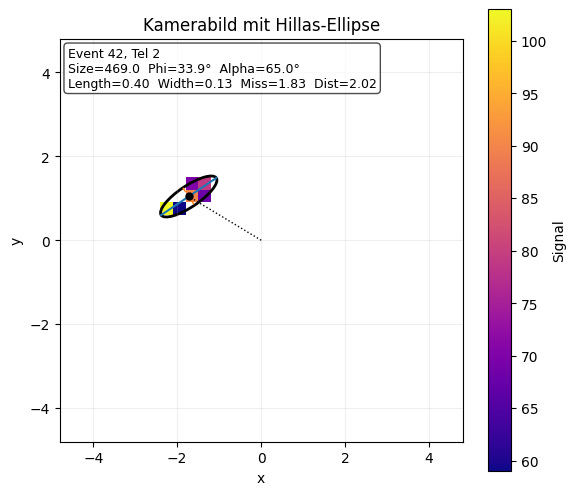

1.8272170241779149


In [30]:
# Beispiel: 32x32, bereits gecleant (0 = maskiert)
cleaned = np.random.poisson(0.1, 32*32).astype(float)
# künstlicher "Bildkern"
cleaned[16*32 + 18] += 30
cleaned[15*32 + 18] += 15
cleaned[17*32 + 19] += 12
cleaned=np.load("crab_2025-10-17_data_cleaned.npy")[0]
df = hillas_from_image(cleaned, shape=(32,32), pixel_pitch=0.3,
                       event_id=42, telescope_id=2, timestamp=1.727e9)
#print(df)

fig, ax = plot_hillas_from_df(
    cleaned, df,
    event_id=42,
    telescope_id=2,
    shape=(32, 32),
    pixel_pitch=0.3,
    k_sigma=2.0
)
plt.show()
print(df.query("Event == 42 and Telescope == 2")["Miss"].iloc[0])

In [31]:
data=np.load("crab_2025-10-17_data_cleaned.npy")
miss=np.zeros(len(data))
alpha=np.zeros(len(data))
dist=np.zeros(len(data))
for i in range(len(data)):
    df=hillas_from_image(data[i], shape=(32,32), pixel_pitch=0.3,
                       event_id=42, telescope_id=2, timestamp=1.727e9)
    miss[i]=df.query("Event == 42 and Telescope == 2")["Miss"].iloc[0]
    alpha[i]=df.query("Event == 42 and Telescope == 2")["Alpha"].iloc[0]
    dist[i]=df.query("Event == 42 and Telescope == 2")["Distance"].iloc[0]

(array([ 94., 111., 112.,  90.,  83.,  89.,  96.,  95.,  96.,  87.,  78.,
         92.,  97.,  93.,  74.,  85.,  82.,  84.,  76.,  85.,  71., 106.,
         84.,  90.,  78.,  88.,  82.,  76.,  77.,  82.,  70.,  82.,  73.,
        102.,  77.,  68.,  61.,  64.,  78.,  68.,  74.,  76.,  85.,  78.,
         76.,  60.,  60.,  66.,  76.,  74.,  54.,  64.,  56.,  53.,  61.,
         42.,  59.,  47.,  69.,  58.,  53.,  49.,  49.,  56.,  63.,  57.,
         65.,  58.,  52.,  79.,  57.,  62.,  75.,  97.,  39.,  44.,  31.,
         31.,  16.,  24.,  21.,  17.,   8.,  11.,  17.,  13.,   7.,   4.,
          8.,   5.,   4.,   3.,   1.,   1.,   2.,   1.,   1.,   1.,   0.,
          4.]),
 array([3.70685598e-04, 6.35964123e-02, 1.26822139e-01, 1.90047866e-01,
        2.53273592e-01, 3.16499319e-01, 3.79725046e-01, 4.42950772e-01,
        5.06176499e-01, 5.69402226e-01, 6.32627952e-01, 6.95853679e-01,
        7.59079406e-01, 8.22305132e-01, 8.85530859e-01, 9.48756586e-01,
        1.01198231e+00, 1.0752

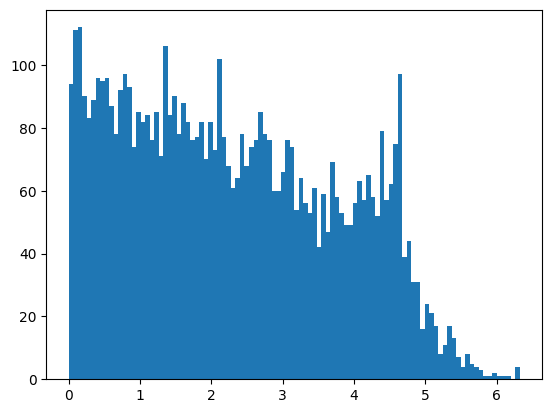

In [36]:
#miss=miss[miss<6]
#alpha=alpha[alpha<6]
plt.hist(miss,bins=100)

In [12]:
df_17=pd.read_csv("crab_2025-10-17_hillas_SNR7.csv")
df_17 = df_17.assign(date="2025-10-17")
cols = ['date'] + [c for c in df_17.columns if c != 'date']
df_17 = df_17[cols]
df_18=pd.read_csv("crab_2025-10-18_hillas_SNR7.csv")
df_18 = df_18.assign(date="2025-10-18")
cols = ['date'] + [c for c in df_18.columns if c != 'date']
df_18 = df_18[cols]
df_19=pd.read_csv("crab_2025-10-19_hillas_SNR7.csv")
df_19 = df_19.assign(date="2025-10-19")
cols = ['date'] + [c for c in df_19.columns if c != 'date']
df_19 = df_19[cols]
df_20=pd.read_csv("crab_2025-10-20_hillas_SNR7.csv")
df_20 = df_20.assign(date="2025-10-20")
cols = ['date'] + [c for c in df_20.columns if c != 'date']
df_20 = df_20[cols]
df_all=pd.concat([df_17, df_18, df_19, df_20], ignore_index=True)
print(df_all)
df_all.to_csv("crab_2025-10_all_hillas_SNR7.csv",index=False)

             date  Event  Telescope     Timestamp     MeanX      StdX  \
0      2025-10-17      1          1  1.760689e+09  1.079571  0.199885   
1      2025-10-17      2          1  1.760689e+09 -2.198395  0.152377   
2      2025-10-17      3          1  1.760689e+09 -0.325664  0.154207   
3      2025-10-17      4          1  1.760689e+09  2.292435  0.240263   
4      2025-10-17      5          1  1.760689e+09  3.369914  0.149727   
...           ...    ...        ...           ...       ...       ...   
22784  2025-10-20   6916          1  1.760964e+09  4.197749  0.443290   
22785  2025-10-20   6917          1  1.760964e+09 -4.375464  0.347216   
22786  2025-10-20   6918          1  1.760964e+09 -3.568548  0.219753   
22787  2025-10-20   6919          1  1.760964e+09 -4.023107  0.422067   
22788  2025-10-20   6920          1  1.760964e+09 -3.888664  0.243135   

          MeanY      StdY         Phi     Size    Length     Width      Miss  \
0     -2.821262  0.281670   89.276177   165

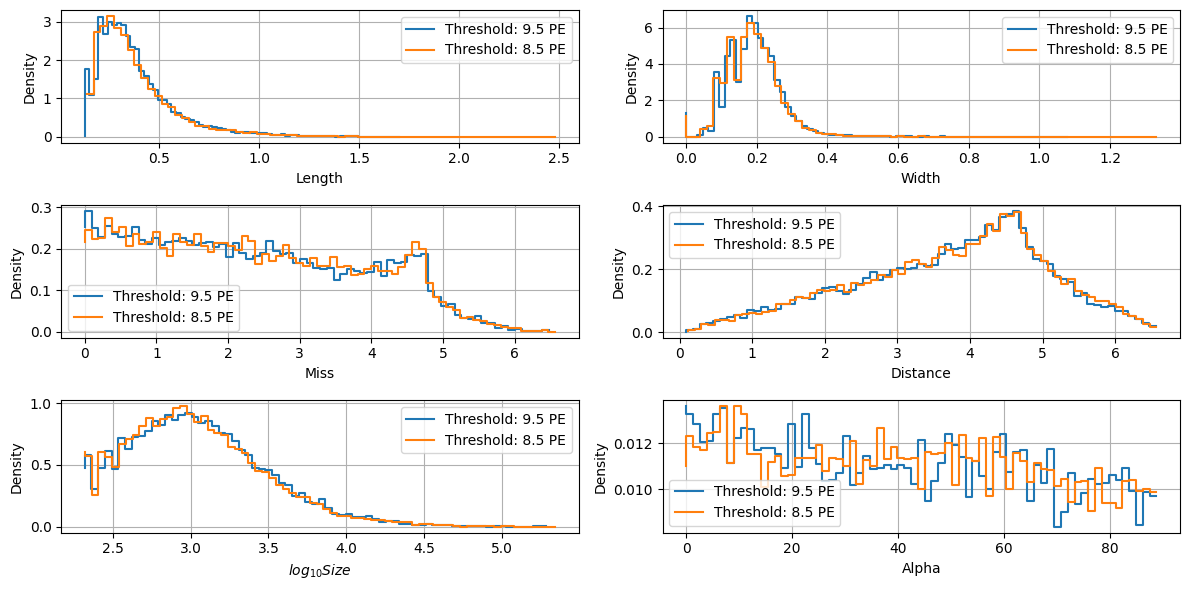

In [5]:
df_all=pd.read_csv("crab_2025-10_all_hillas.csv")
params=["Length","Width","Miss","Distance","Size","Alpha"]
fig, axes = plt.subplots(3, 2, figsize=(12, 6))

# Flatten for easy iteration
axes = axes.flatten()

for i in range(6):
    param=params[i]
    mask = df_all["date"].isin(["2025-10-17", "2025-10-18"])
    values = df_all.loc[mask, param]
    miss_95=values.to_numpy()
    mask = df_all["date"].isin(["2025-10-19", "2025-10-20"])
    values = df_all.loc[mask, param]
    miss_85=values.to_numpy()
    if (param=="Size"):
        miss_95=np.log(miss_95)/np.log(10)
        miss_85=np.log(miss_85)/np.log(10)
        axes[i].set_xlabel(r"$log_{10} Size$")
    else:
        axes[i].set_xlabel(param)
    y,x=np.histogram(miss_95,bins=70,density=True)
    axes[i].step(x[:-1],y,label="Threshold: 9.5 PE")
    y,x=np.histogram(miss_85,bins=70,density=True)
    axes[i].step(x[:-1],y,label="Threshold: 8.5 PE")
    axes[i].set_ylabel('Density')
    axes[i].grid()
    axes[i].legend()

plt.tight_layout()
#plt.savefig("Crab_2025-10_Hillas_dist_threshold.png",dpi=300)
plt.show()

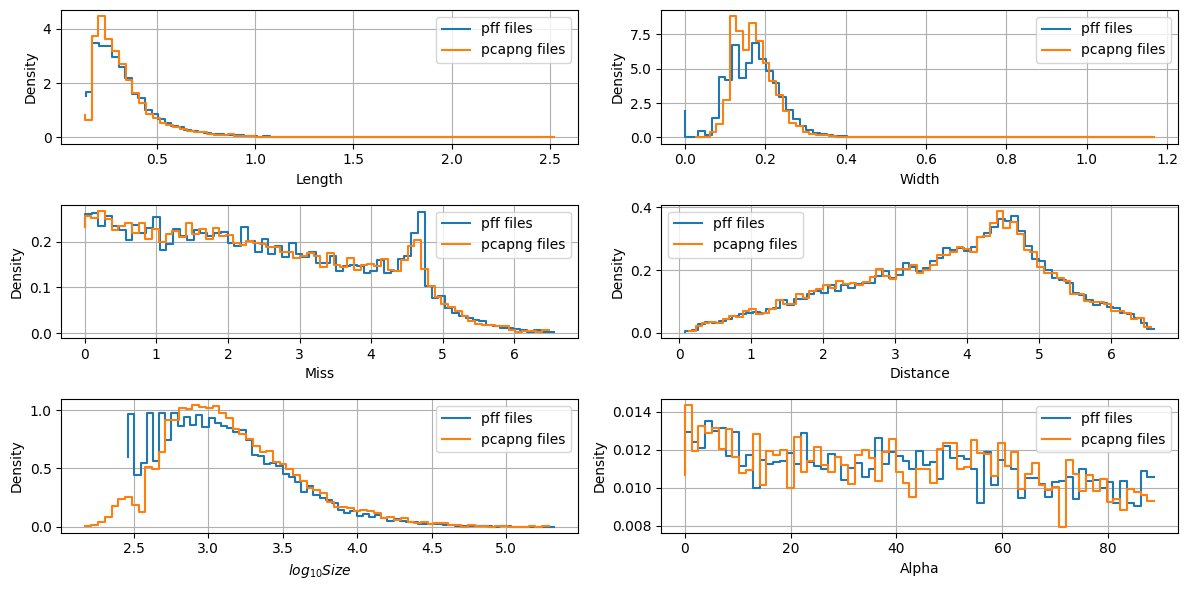

In [14]:
df_pff=pd.read_csv("crab_2025-10_all_hillas_SNR7.csv")
df_pcapng=pd.read_csv("../../../Jamie_processing/for_Elisa/crab_2025-10_all_hillas_pcapng.csv")
params=["Length","Width","Miss","Distance","Size","Alpha"]
fig, axes = plt.subplots(3, 2, figsize=(12, 6))

# Flatten for easy iteration
axes = axes.flatten()

for i in range(6):
    param=params[i]
    values_pff = df_pff[param].to_numpy()
    values_pcapng = df_pcapng[param].to_numpy()
    if (param=="Size"):
        values_pff=np.log(values_pff)/np.log(10)
        values_pcapng=np.log(values_pcapng)/np.log(10)
        axes[i].set_xlabel(r"$log_{10} Size$")
    else:
        axes[i].set_xlabel(param)
    y,x=np.histogram(values_pff,bins=70,density=True)
    axes[i].step(x[:-1],y,label="pff files")
    y,x=np.histogram(values_pcapng,bins=70,density=True)
    axes[i].step(x[:-1],y,label="pcapng files")
    axes[i].set_ylabel('Density')
    axes[i].grid()
    axes[i].legend()

plt.tight_layout()
plt.savefig("Crab_2025-10_Hillas_dist_files_comp.png",dpi=300)
plt.show()